# Risk-Parity + Trend — a quantitative teardown 🔬
### excess-vs-excess Sharpe race · paired Sharpe-diff bootstrap · two-era cut · 200-seed shuffled-gate placebo · cost sweep · a two-world synthetic control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — *add a 200-day trend gate to an inverse-vol risk-parity book and improve the excess-of-cash Sharpe and the drawdown* — splits into a **risk claim** (shallower drawdown, beyond mere de-risking) and a **return claim** (a genuine Sharpe / excess-return advantage). We grade them separately, on the tape.

> ⚠️ **Data note.** yfinance daily total-return SPY/TLT/GLD/DBC (sleeves) + BIL (cash), 2008-04-01 → 2026-06-30 (4,591 race bars after the 200d SMA + 60d vol burn-in, ann = 252; both legs excess-of-cash minus BIL). Four young, hand-picked sleeves on one 18-year survivor tape — named on the Signal axis. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `003721e41f89`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rp_trend import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_prices()
    RET = st.daily_returns(PX)
    CASH = RET[data.CASH]
    RACE = st.race(PX, RET, CASH, data.SLEEVES)     # headline, gross, excess-of-cash
else:
    PX = RET = CASH = RACE = None
print("real ETF cache present:", HAVE_REAL,
      "| race days:", (0 if RACE is None else RACE["n_days"]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2008-04-01', 'end': '2026-06-30', 'years': 18.2, 'n_days': 4591, 'n_cache': 4802, 'lookback': 60, 'sma': 200, 'p_cagr': 6.94, 'p_vol': 9.42, 'p_sharpe': 0.626, 'p_dd': -19.95, 'p_wealth': 3.39, 't_cagr': 6.15, 't_vol': 7.11, 't_sharpe': 0.702, 't_dd': -9.68, 't_wealth': 2.97, 'sharpe_adv': 0.077, 'dd_relief': 10.28, 'ret_diff': -0.93, 't_ret': -0.65, 'avg_gate': 63.5, 'avg_risky': 0.646, 'turn_plain': 0.99, 'turn_trend': 2.4, 'bs_obs': 0.077, 'bs_lo': -0.248, 'bs_hi': 0.392, 'bs_p': 0.672, 'eras': [('era 1  2008-04 -> 2017-05', 0.502, 0.684, 0.181, -19.27, -9.68, 0.08), ('era 2  2017-05 -> 2026-06', 0.749, 0.722, -0.027, -19.95, -8.85, -1.09)], 'crises': [('2008 GFC', -19.27, -7.84), ('2020 COVID', -16.6, -7.14), ('2022 bond bear', -19.95, -8.76)], 'costs': [(0, 0.626, 0.702, 0.077, -19.95, -9.68, 6.94, 6.15, -0.65), (5, 0.62, 0.686, 0.065, -19.97, -9.75, 6.88, 6.03, -0.7), (10, 0.615, 0.669, 0.054, -20.0, -9.88, 6.83, 5.9, -0.74), (20, 0.604, 0.635, 0.031, -20.04, -10.33, 6.72, 5.65, -0.84)], 'pl_obs_adv': 0.077, 'pl_mean_adv': -0.049, 'pl_p_sharpe': 0.135, 'pl_obs_dd': -9.68, 'pl_mean_dd': -17.13, 'pl_p_dd': 0.0, 'pl_seeds': 200, 'cal': [(2008, -2.39, 10.14), (2009, 7.55, 3.87), (2010, 19.06, 12.55), (2011, 12.3, 8.07), (2012, 7.21, -2.5), (2013, -4.26, 4.95), (2014, 0.57, 4.73), (2015, -9.17, -1.89), (2016, 10.6, 5.15), (2017, 13.11, 9.06), (2018, -2.74, -1.34), (2019, 17.48, 12.36), (2020, 12.85, 9.58), (2021, 13.98, 11.67), (2022, -9.43, -3.17), (2023, 9.08, 3.24), (2024, 11.87, 9.93), (2025, 18.9, 14.6), (2026, 6.7, 3.59)], 'syn_null_adv': -0.175, 'syn_null_dd': 4.05, 'syn_null_share': 15, 'syn_pl_adv': 0.254, 'syn_pl_dd': 35.7, 'syn_pl_t': 2.0, 'syn_pl_share': 90, 'fingerprint': '003721e41f89'}


real ETF cache present: True | race days: 4591


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | *Real on the drawdown:* max DD **-9.68% vs -19.95%**, robust in both eras & every crisis, shuffled-gate placebo **p = 0.000** (200 seeds). *Weak on the Sharpe:* advantage **+0.077**, bootstrap 95% CI **[-0.25, +0.39]** (straddles 0), excess-ret diff -0.93%/yr (HAC t = -0.65), sign flips era-to-era. |
| **Tradability** | `FRAGILE` | Turnover 2.40× NAV/yr, penny-spread ETFs, no borrow; survives 20 bps (adv +0.031). But the certified deliverable is risk control; terminal wealth ×3.0 vs ×3.4. |

> 💡 In plain words: the crash shield is real and certified; the free lunch is not on this tape.

## 1 · The construction, precisely

Four sleeves $i \in \{$SPY, TLT, GLD, DBC$\}$. Each month $m$, on information known at the prior close:

$$w_i = \frac{1/\hat\sigma_i}{\sum_j 1/\hat\sigma_j}, \qquad g_i = \mathbf{1}\{P_i \ge \mathrm{SMA}_{200}(P_i)\},$$

with $\hat\sigma_i$ the trailing 60-day realized vol. **Plain RP** holds $w_i$ in each sleeve; **RP+trend** holds the *effective* weight $w_i g_i$ and parks the complement $\sum_i w_i(1-g_i)$ in cash (BIL). Both are held through the month (one `shift(1)` lag). Because $\sum_i w_i = 1$, the excess-of-cash returns are

$$r^{plain}_t - c_t = \sum_i w_i (r_{i,t} - c_t), \qquad r^{trend}_t - c_t = \sum_i w_i\, g_i\, (r_{i,t} - c_t),$$

so the gate simply **zeroes a sleeve's excess contribution while it is below trend** — it never re-levers into the survivors.

- **H₁ (risk).** RP+trend cuts max drawdown beyond what any same-frequency exposure profile would (timing, not de-risking).
- **H₂ (return).** RP+trend earns a positive **excess-vs-excess Sharpe advantage** whose bootstrap CI clears zero and holds across sub-eras.

We find **H₁ supported** (DD placebo p = 0.000, robust both eras) and **H₂ unsupported** (Sharpe adv +0.077, CI through zero, sign flips era-to-era).

## 2 · So what? — the two inference traps

1. **Exposure confound.** The gated book sits in cash ~35% of sleeve-months, so ANY same-frequency de-risking mechanically shrinks the drawdown. The shield only counts if it beats *shuffled* gates — same time-out-of-market per sleeve, no alignment with the actual downtrend (200 seeds; the desk bans single-seed baselines).
2. **Serial correlation + a paired comparison.** Daily excess returns are autocorrelated (vol clustering) and the two books share the same tape, so the return test is a **HAC (Newey-West) t on the paired daily excess difference**, and the Sharpe-advantage CI is a **paired circular block-bootstrap** of the Sharpe *difference* (21-day blocks, the pairing preserved).

Everything is **excess-vs-excess** (both legs minus BIL), so the risk-free convention cancels and we compare like with like.

## 3 · How we'd know — the protocol

- **Tape.** 4,802 daily total-return closes, 2008-04-01 → 2026-06-30 (18 yrs of race sample, 4,591 days), as-of pinned, fingerprint `003721e41f89`.
- **Books.** Plain RP vs RP+trend, monthly, one lag; de-risked sleeves earn BIL.
- **Headline stats.** CAGR, ann vol, Sharpe (excess-of-cash), max DD, terminal wealth; **HAC t on the daily excess-return difference**; **paired Sharpe-diff bootstrap**.
- **Robustness.** Two-era cut; a per-crisis drawdown ledger; a calendar-year table.
- **Placebo.** 200 shuffled-gate seeds → p-values for the Sharpe advantage and the DD shield.
- **Costs.** One-way bps × turnover × NAV per monthly rebalance (long-or-cash, no borrow): 0 / 5 / 10 / 20 bps.
- **Positive control.** Seeded bull/bear-regime worlds: a no-downtrend null (the gate must not help) vs a planted-bear world (it must light up), 20 seeds each.

## 4 · The teardown

### 4a · The headline race and the Sharpe-difference bootstrap

Both books' full stats, then the paired block-bootstrap of the Sharpe *difference* — the direct test of the Sharpe-advantage claim.

plain RP : CAGR  +6.94%  vol  9.42%  Sharpe +0.626  maxDD  -19.95%  wealth x3.39
RP+trend : CAGR  +6.15%  vol  7.11%  Sharpe +0.702  maxDD   -9.68%  wealth x2.97
Sharpe advantage +0.077  |  drawdown relief +10.28 pp
excess-ret diff -0.93%/yr  HAC t = -0.65


Sharpe-diff bootstrap: obs +0.077  95% CI [-0.248, +0.392]  P(>0)=0.672


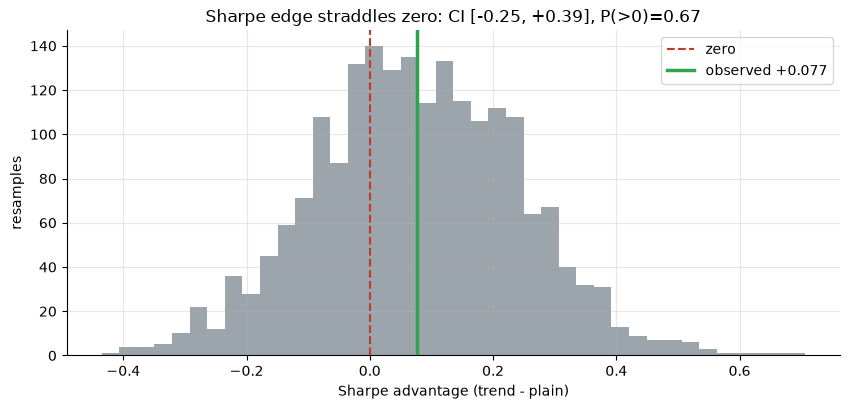

In [2]:
if HAVE_REAL:
    for leg, p in (('plain RP', RACE['plain']), ('RP+trend', RACE['trend'])):
        print(f"{leg:<9}: CAGR {p['cagr_pct']:+6.2f}%  vol {p['vol_ann_pct']:5.2f}%  "
              f"Sharpe {p['sharpe']:+.3f}  maxDD {p['maxdd_pct']:+7.2f}%  wealth x{p['wealth_mult']:.2f}")
    print(f"Sharpe advantage {RACE['sharpe_adv']:+.3f}  |  drawdown relief {RACE['dd_relief_pp']:+.2f} pp")
    print(f"excess-ret diff {RACE['ret_diff_ann_pct']:+.2f}%/yr  HAC t = {RACE['t_ret_diff']:+.2f}")
    bs = st.sharpe_diff_bootstrap(RACE['trend_excess'], RACE['plain_excess'], n_boot=2000)
    print(f"Sharpe-diff bootstrap: obs {bs['obs']:+.3f}  95% CI [{bs['lo']:+.3f}, {bs['hi']:+.3f}]  P(>0)={bs['p_gt0']:.3f}")
    fig, ax = plt.subplots(figsize=(8.6, 4.2))
    rng = np.random.default_rng(896); a = RACE['trend_excess'].to_numpy(); b = RACE['plain_excess'].to_numpy()
    n = len(a); draws = []
    for _ in range(2000):
        st_ = (rng.integers(0, n, int(np.ceil(n/21)))[:,None] + np.arange(21)[None,:]).ravel() % n
        st_ = st_[:n]; sa, sb = a[st_], b[st_]
        draws.append(sa.mean()/sa.std(ddof=1)*np.sqrt(252) - sb.mean()/sb.std(ddof=1)*np.sqrt(252))
    ax.hist(draws, bins=40, color=GREY, alpha=.85)
    ax.axvline(0, c=RED, lw=1.5, ls='--', label='zero')
    ax.axvline(bs['obs'], c=GREEN, lw=2.5, label=f"observed {bs['obs']:+.3f}")
    ax.set_xlabel('Sharpe advantage (trend - plain)'); ax.set_ylabel('resamples')
    ax.set_title(f"Sharpe edge straddles zero: CI [{bs['lo']:+.2f}, {bs['hi']:+.2f}], P(>0)={bs['p_gt0']:.2f}")
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print('cache missing - frozen:', {k: R[k] for k in ('p_sharpe','t_sharpe','sharpe_adv','bs_lo','bs_hi','bs_p','t_ret')})

> 💡 In plain words: the gate lifts the Sharpe from 0.63 to 0.70 and halves the drawdown — but the Sharpe *advantage* (+0.077) has a bootstrap CI of **[-0.25, +0.39]** and only a 67% chance of being positive. The excess-return leg is actually slightly negative (-0.93%/yr, t = -0.65): the gate trades a little return for a lot less risk. Uncertified as an edge.

### 4b · Two eras — the Sharpe edge doesn't hold, the shield does

Split the 18 years in half. A real edge should survive both.

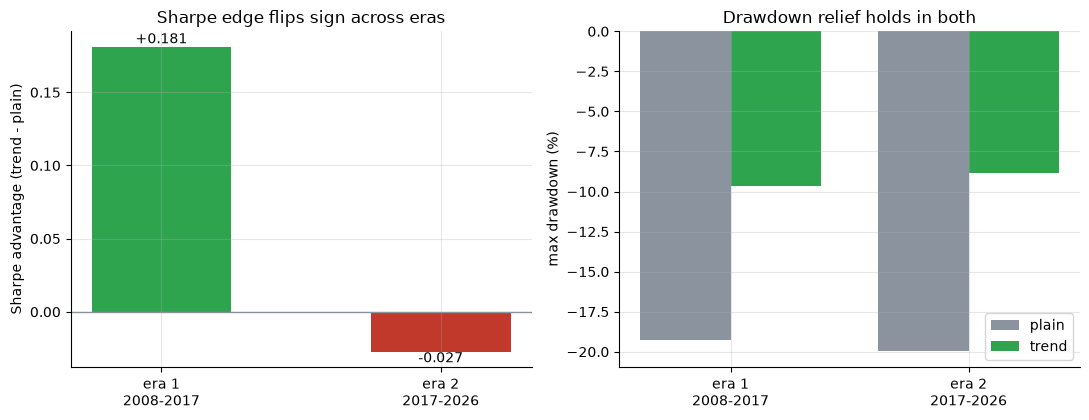

era 1: Sharpe +0.502->+0.684 (adv +0.181)  maxDD -19.27%->-9.68%  t_ret +0.08
era 2: Sharpe +0.749->+0.722 (adv -0.027)  maxDD -19.95%->-8.85%  t_ret -1.09


In [3]:
rows = R['eras']
if HAVE_REAL:
    rows = [(e['era'], e['sharpe_plain'], e['sharpe_trend'], e['sharpe_adv'],
             e['maxdd_plain_pct'], e['maxdd_trend_pct'], e['t_ret_diff'])
            for e in st.era_cut(PX, RET, CASH, data.SLEEVES)]
labels = ['era 1\n2008-2017', 'era 2\n2017-2026']
advs = [r[3] for r in rows]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(labels, advs, color=[GREEN if v>0 else RED for v in advs], width=.5)
a1.axhline(0, c=GREY, lw=1); a1.set_ylabel('Sharpe advantage (trend - plain)')
a1.set_title('Sharpe edge flips sign across eras')
for i,v in enumerate(advs): a1.annotate(f'{v:+.3f}', (i, v), ha='center', va='bottom' if v>=0 else 'top')
xx = np.arange(2); w = .38
a2.bar(xx-w/2, [r[4] for r in rows], w, color=GREY, label='plain')
a2.bar(xx+w/2, [r[5] for r in rows], w, color=GREEN, label='trend')
a2.set_xticks(xx); a2.set_xticklabels(labels); a2.set_ylabel('max drawdown (%)')
a2.set_title('Drawdown relief holds in both'); a2.legend(loc='lower right')
plt.tight_layout(); plt.show()
for r in rows:
    print(f'{r[0]}: Sharpe {r[1]:+.3f}->{r[2]:+.3f} (adv {r[3]:+.3f})  maxDD {r[4]:+.2f}%->{r[5]:+.2f}%  t_ret {r[6]:+.2f}')

> 💡 In plain words: era 1 (crisis-dense: GFC, euro crisis) gives the gate a **+0.181** Sharpe edge; era 2 (a long bull with brief shocks) gives **-0.027** — it *inverts*. The whole Sharpe story is the 2008–2011 window. The drawdown relief, by contrast, is a clean halving in **both** eras. That's the signature of risk control without a return edge.

### 4c · The placebo — timing, or just holding less?

200 shuffled-gate books: each sleeve keeps its on/off *frequency* but the gate is permuted across months (no alignment with the actual downtrend). If the real book's drawdown/Sharpe sit inside the shuffled cloud, the "skill" was mere de-risking.

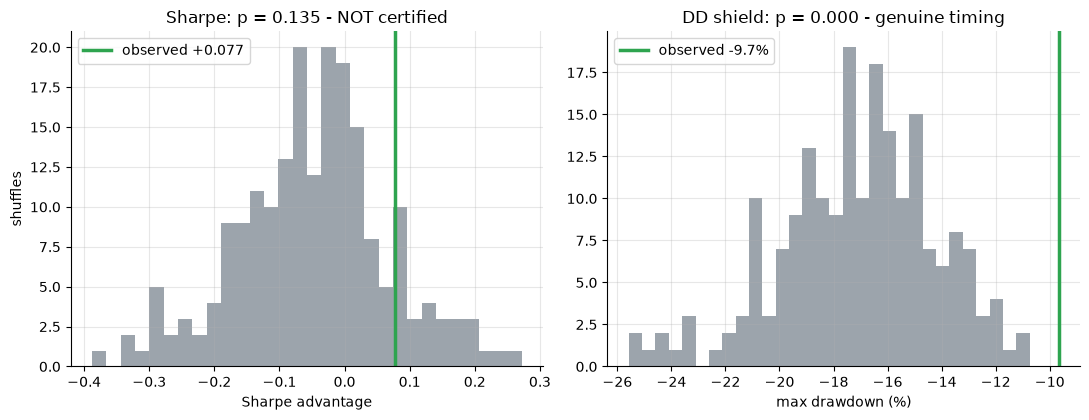

Sharpe adv: obs +0.077 vs placebo mean -0.049  p=0.135
maxDD: obs -9.68% vs placebo mean -17.13%  p=0.000


In [4]:
if HAVE_REAL:
    pl = st.placebo_shuffle(PX, RET, CASH, data.SLEEVES, n_seeds=200)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
    a1.hist(pl['adv_draws'], bins=30, color=GREY, alpha=.85)
    a1.axvline(pl['obs_sharpe_adv'], c=GREEN, lw=2.5, label=f"observed {pl['obs_sharpe_adv']:+.3f}")
    a1.set_xlabel('Sharpe advantage'); a1.set_ylabel('shuffles')
    a1.set_title(f"Sharpe: p = {pl['p_sharpe']:.3f} - NOT certified"); a1.legend()
    a2.hist(pl['dd_draws'], bins=30, color=GREY, alpha=.85)
    a2.axvline(pl['obs_maxdd_pct'], c=GREEN, lw=2.5, label=f"observed {pl['obs_maxdd_pct']:.1f}%")
    a2.set_xlabel('max drawdown (%)')
    a2.set_title(f"DD shield: p = {pl['p_dd']:.3f} - genuine timing"); a2.legend()
    plt.tight_layout(); plt.show()
    print(f"Sharpe adv: obs {pl['obs_sharpe_adv']:+.3f} vs placebo mean {pl['placebo_mean_adv']:+.3f}  p={pl['p_sharpe']:.3f}")
    print(f"maxDD: obs {pl['obs_maxdd_pct']:+.2f}% vs placebo mean {pl['placebo_mean_maxdd_pct']:+.2f}%  p={pl['p_dd']:.3f}")
else:
    print('cache missing - frozen: p_sharpe %.3f  p_dd %.3f' % (R['pl_p_sharpe'], R['pl_p_dd']))

> 💡 In plain words: random same-frequency gates get you a **-17%** drawdown; the *timed* gate gets **-9.7%**, and **0 of 200** shuffles match it (p = 0.000) — the shield is *information*, not dilution. The Sharpe advantage, though, is beaten by ~1 shuffle in 7 (p = 0.135): not certifiable. This is the cleanest statement of the split verdict.

### 4d · Costs — cheap to run, and it doesn't change the story

Turnover is 2.40× NAV/yr (vs 0.99× for plain RP); the books are long-or-cash so there is no borrow leg.

In [5]:
rows = R['costs']
if HAVE_REAL:
    rows = [(c['cost_bps'], c['sharpe_plain'], c['sharpe_trend'], c['sharpe_adv'],
             c['maxdd_plain_pct'], c['maxdd_trend_pct'], c['cagr_plain_pct'],
             c['cagr_trend_pct'], c['t_ret_diff']) for c in st.cost_sweep(PX, RET, CASH, data.SLEEVES)]
print(f"{'cost':>6} | {'Sh plain':>9} {'Sh trend':>9} {'adv':>7} | {'maxDD p/t':>16} | {'t_ret':>6}")
for cb, shp, sht, adv, ddp, ddt, cgp, cgt, tr in rows:
    print(f'{cb:>4.0f}bp | {shp:>9.3f} {sht:>9.3f} {adv:>+7.3f} | {ddp:>7.2f}%/{ddt:>6.2f}% | {tr:>+6.2f}')

  cost |  Sh plain  Sh trend     adv |        maxDD p/t |  t_ret
   0bp |     0.626     0.702  +0.077 |  -19.95%/ -9.68% |  -0.65
   5bp |     0.620     0.686  +0.065 |  -19.97%/ -9.75% |  -0.70
  10bp |     0.615     0.669  +0.054 |  -20.00%/ -9.88% |  -0.74
  20bp |     0.604     0.635  +0.031 |  -20.04%/-10.33% |  -0.84


> 💡 In plain words: even at a punitive 20 bps one-way, the Sharpe advantage only slides +0.077 → +0.031 and the drawdown shield is intact. Costs are **not** the problem with this strategy; the absent certified edge is. What fails the bar gross fails it net.

### 4e · Faithful-engine & power control — we know the truth here

Two seeded bull/bear-regime worlds, 20 seeds each: a **no-downtrend null** (edge=0, the gate must earn nothing) and a **planted-bear world** (edge=1, sustained down-grinds the 200-day gate should step out of — it MUST light up).

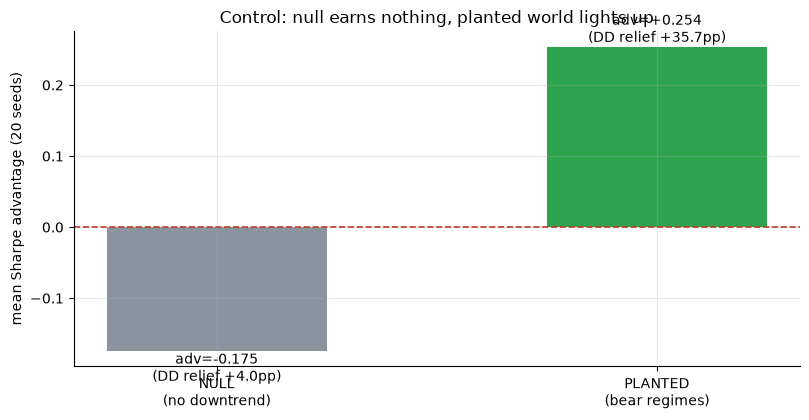

null    : mean Sharpe adv -0.175 +/- 0.157  DD relief +4.05pp  share adv>0 15%
planted : mean Sharpe adv +0.254 +/- 0.231  DD relief +35.70pp  share adv>0 90%


In [6]:
res = [st.synthetic_check(edge=e, n_seeds=20) for e in (0.0, 1.0)]
fig, ax = plt.subplots(figsize=(8.2, 4.3))
labels = ['NULL\n(no downtrend)', 'PLANTED\n(bear regimes)']
advs = [r['mean_sharpe_adv'] for r in res]
ax.bar(labels, advs, color=[GREY, GREEN], width=.5)
ax.axhline(0, c=RED, lw=1.2, ls='--')
for i, r in enumerate(res):
    ax.annotate(f"adv={r['mean_sharpe_adv']:+.3f}\n(DD relief {r['mean_dd_relief_pp']:+.1f}pp)",
                (i, r['mean_sharpe_adv']), ha='center', va='bottom' if advs[i]>=0 else 'top')
ax.set_ylabel('mean Sharpe advantage (20 seeds)')
ax.set_title('Control: null earns nothing, planted world lights up')
plt.tight_layout(); plt.show()
for name, r in zip(('null', 'planted'), res):
    print(f"{name:<8}: mean Sharpe adv {r['mean_sharpe_adv']:+.3f} +/- {r['sd_sharpe_adv']:.3f}  "
          f"DD relief {r['mean_dd_relief_pp']:+.2f}pp  share adv>0 {r['share_adv_pos']*100:.0f}%")

> 💡 In plain words: with no persistent downtrend the gate only adds whipsaw — it *hurts* the Sharpe (mean -0.175, positive on only 15% of seeds), exactly as a null should. Plant sustained bear regimes and the same gate lifts the Sharpe (mean +0.254, positive on 90% of seeds) and cuts drawdown ~36 pp. The machinery can bank a real trend premium when one exists — so the thin real-tape edge is the tape talking, not a blind harness. *(A faithful-engine / power check only — never cited in support of a stamp.)*

## 5 · The verdict

- **Signal `MIXED`** — *Real on the drawdown:* max DD **-9.68% vs -19.95%** (halved), robust in both eras and every crisis window (2008, 2020, 2022 each cut ~in half), certified as timing by the shuffled-gate placebo (**p = 0.000**, 200 seeds; placebo mean DD -17.13%). *Weak on the Sharpe:* advantage **+0.077**, bootstrap CI **[-0.25, +0.39]** through zero, excess-ret diff -0.93%/yr (HAC t = -0.65), sign flips era-to-era. Four young survivor sleeves on one 18-year tape, named.
- **Tradability `FRAGILE`** — turnover 2.40× NAV/yr, penny-spread ETFs, no borrow, robust to 20 bps (adv +0.031). But the certified deliverable is risk control — terminal wealth ×3.0 vs ×3.4, and the uncertified Sharpe edge rests on one crisis-front-loaded tape. Not INVESTABLE as an *edge*; deployable as a *shield*.
- **In one line:** adding trend to risk-parity **genuinely halves the drawdown** but **does not certifiably improve the Sharpe** — a Mixed signal in a cheap-to-run Fragile vehicle.

## 6 · Going further

- **Why no Sharpe pop?** The 200-day gate catches the *long* grinds (2008, 2022) but whipsaws in ranges and lags every turn by construction. The premiums it misses in bull years roughly offset the crashes it prevents — hence a halved drawdown but a flat, uncertified Sharpe.
- **Risk overlay vs return engine.** The DD placebo (p = 0.000) is the study's most durable fact: a trailing 200-day filter *forecasts* which sleeve is about to keep falling. That is bankable as **position sizing / risk control** even though the Sharpe edge never certifies.
- **The obvious next studies.** A faster gate, gating the whole book on its own equity curve rather than sleeve-by-sleeve, or re-levering the risk budget onto the surviving sleeves instead of parking in cash. Compare [68-all-weather](../../68-all-weather/README.md) (the plain book), [110-faber-timing](../../110-faber-timing/README.md) (the single-asset gate) and [894-trend-6040](../../894-trend-6040/README.md) (trend on 60/40).

*The reproducible core is offline and deterministic; the signal is the per-sleeve 200-day SMA gate with one month of lag. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*